# 3D KLT particle picking on the TomoTwin 2df7 simulation

This notebook follows the full algorithm manually, in the spirit of
`notebooks/spheres.ipynb`. It intentionally does **not** call
`KLTParticleDetector3D.process_tomogram()`.

We inspect:

1. the realistic TomoTwin reconstruction and 2df7 ground truth;
2. non-overlapping patches and their variance distribution;
3. patch PSDs, radial averaging, ALS, and variance calibration;
4. prewhitening and the second PSD/RPSD estimate;
5. Fredholm eigenvalues/eigenfunctions across angular orders;
6. complete spherical-harmonic template multiplets;
7. the likelihood score volume;
8. diameter-scale NMS and one-to-one ground-truth evaluation.

The default `128^3` ROI contains realistic missing-wedge/noise artifacts,
other protein classes, vesicles, and fiducials. Change `ROI_START_ZYX` and
`ROI_SIZE` to investigate other regions or expand to the full volume.

In [1]:
from pathlib import Path
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import mrcfile
import numpy as np
import pandas as pd
import scipy
from scipy.optimize import linear_sum_assignment

from scipy.spatial.distance import cdist

from kltpicker_3d.alt_least_squares import alternating_least_squares_solver
from kltpicker_3d.fredholm_solver import solve_radial_fredholm_equation
from kltpicker_3d.spectral_estimation import estimate_isotropic_powerspectrum_tensor
from kltpicker_3d.tomogram import KLTParticleDetector3D
from kltpicker_3d.utils import (
    bandpass_filter_3d,
    calibrate_radial_psds,
    expand_spherical_harmonic_templates,
    generate_uniform_radial_sampling_points,
    prewhiten_tomogram,
    radial_average_jax,
    ranked_local_maxima_nms_3d,
    radial_mode_truncation_index,
    radial_psd_to_variance,
    trigonometric_interpolation,
)

jax.config.update("jax_platform_name", "cpu")
plt.rcParams.update({
    "figure.figsize": (8, 4),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "image.cmap": "gray",
})
print("JAX devices:", jax.devices())

JAX devices: [CpuDevice(id=0)]


## Configuration

TomoTwin reports a 33-voxel box for 2df7. At 10.204 Å/voxel this is about
337 Å. Geometry below is kept explicitly in voxel units.

In [2]:
DATA_DIR = Path("data/tomotwin_2df7")
TOMOGRAM_PATH = DATA_DIR / "tiltseries_rec.mrc"
POSITIONS_PATH = DATA_DIR / "particle_positions.txt"

TARGET_CLASS = "2df7"
PARTICLE_DIAMETER_VOXELS = 33
PSD_PATCH_FRACTION = 0.8
FREDHOLM_RADIUS_FRACTION = 0.5
BANDPASS_LOW_FRACTION = 0.05
BANDPASS_HIGH_FRACTION = 0.05
BANDLIMIT = np.pi

ROI_START_ZYX = np.array([24, 16, 304])
ROI_SIZE = 128

LEGENDRE_ORDER = 40
MAX_ANGULAR_ORDER = 4
ALS_MAX_ITER = 500
ENERGY_FRACTION = 0.99
# Diagnostic assumption: the number of fully evaluable 2df7 particles is known.
KNOWN_PARTICLE_COUNT = 7
MATCH_TOLERANCE = PARTICLE_DIAMETER_VOXELS / 2

assert TOMOGRAM_PATH.exists(), f"Missing {TOMOGRAM_PATH}"
assert POSITIONS_PATH.exists(), f"Missing {POSITIONS_PATH}"

def odd_floor(value):
    value = int(np.floor(value))
    return value if value % 2 else value - 1

PSD_PATCH_SIZE = odd_floor(PSD_PATCH_FRACTION * PARTICLE_DIAMETER_VOXELS)
FREDHOLM_RADIUS = FREDHOLM_RADIUS_FRACTION * PARTICLE_DIAMETER_VOXELS
TEMPLATE_SIDE = 2 * int(np.ceil(FREDHOLM_RADIUS)) + 1
SPECTRUM_SIZE = 2 * PSD_PATCH_SIZE - 1

print({
    "particle_diameter_voxels": PARTICLE_DIAMETER_VOXELS,
    "psd_patch_size": PSD_PATCH_SIZE,
    "fredholm_radius": FREDHOLM_RADIUS,
    "template_side": TEMPLATE_SIDE,
    "spectrum_size": SPECTRUM_SIZE,
})

{'particle_diameter_voxels': 33, 'psd_patch_size': 25, 'fredholm_radius': 16.5, 'template_side': 35, 'spectrum_size': 49}


## Load the reconstruction and ground truth

MRC arrays are indexed `(z, y, x)`, while `particle_positions.txt` stores
`(x, y, z)`. We convert coordinates once and use `(z, y, x)` everywhere.

In [3]:
with mrcfile.open(TOMOGRAM_PATH, permissive=True) as mrc:
    full_tomogram = np.asarray(mrc.data, dtype=np.float32)
    voxel_size_xyz = np.array([
        float(mrc.voxel_size.x),
        float(mrc.voxel_size.y),
        float(mrc.voxel_size.z),
    ])

columns = ["class", "x", "y", "z", "rot1", "rot2", "rot3"]
positions = pd.read_csv(POSITIONS_PATH, header=None, names=columns)
target_xyz = positions.loc[
    positions["class"].str.lower() == TARGET_CLASS.lower(),
    ["x", "y", "z"],
].to_numpy()
target_zyx = target_xyz[:, ::-1]

print("Tomogram shape (z,y,x):", full_tomogram.shape)
print("Voxel size (x,y,z), Å:", voxel_size_xyz)
print("Intensity mean/std:", full_tomogram.mean(), full_tomogram.std())
display(positions.groupby("class").size().rename("count").to_frame())

Tomogram shape (z,y,x): (200, 512, 512)
Voxel size (x,y,z), Å: [10.20408154 10.20408154 10.20408154]


Intensity mean/std: 21.00976 67.50868


,count
class,
1avo,91
1e9r,93
1fpy,97
1fzg,93
1jz8,91
1oao,94
2df7,100
fiducial,8
vesicle,4


In [4]:
roi_stop = ROI_START_ZYX + ROI_SIZE
roi_slices = tuple(slice(int(a), int(b)) for a, b in zip(ROI_START_ZYX, roi_stop))
raw_tomogram = full_tomogram[roi_slices].copy()
tomogram = np.asarray(bandpass_filter_3d(
    raw_tomogram,
    low_fraction=BANDPASS_LOW_FRACTION,
    high_fraction=BANDPASS_HIGH_FRACTION,
    normalize=True,
))

inside_roi = np.all(
    (target_zyx >= ROI_START_ZYX) & (target_zyx < roi_stop),
    axis=1,
)
gt_all = target_zyx[inside_roi] - ROI_START_ZYX

margin = PARTICLE_DIAMETER_VOXELS / 2
evaluable = np.all(
    (gt_all >= margin) & (gt_all < ROI_SIZE - margin),
    axis=1,
)
gt = gt_all[evaluable]
assert len(gt) == KNOWN_PARTICLE_COUNT, (
    f"Expected {KNOWN_PARTICLE_COUNT} evaluable particles, found {len(gt)}. "
    "Update the known count if the ROI changes."
)

print("ROI:", tuple(ROI_START_ZYX), "to", tuple(roi_stop))
print("2df7 centers in ROI:", len(gt_all))
print("Fully evaluable centers:", len(gt))
print("Raw ROI mean/std:", raw_tomogram.mean(), raw_tomogram.std())
print("Band-passed ROI mean/std:", tomogram.mean(), tomogram.std())

ROI: (np.int64(24), np.int64(16), np.int64(304)) to (np.int64(152), np.int64(144), np.int64(432))
2df7 centers in ROI: 12
Fully evaluable centers: 7
Raw ROI mean/std: 21.13084 70.2212
Band-passed ROI mean/std: -2.9649527e-10 0.93045217


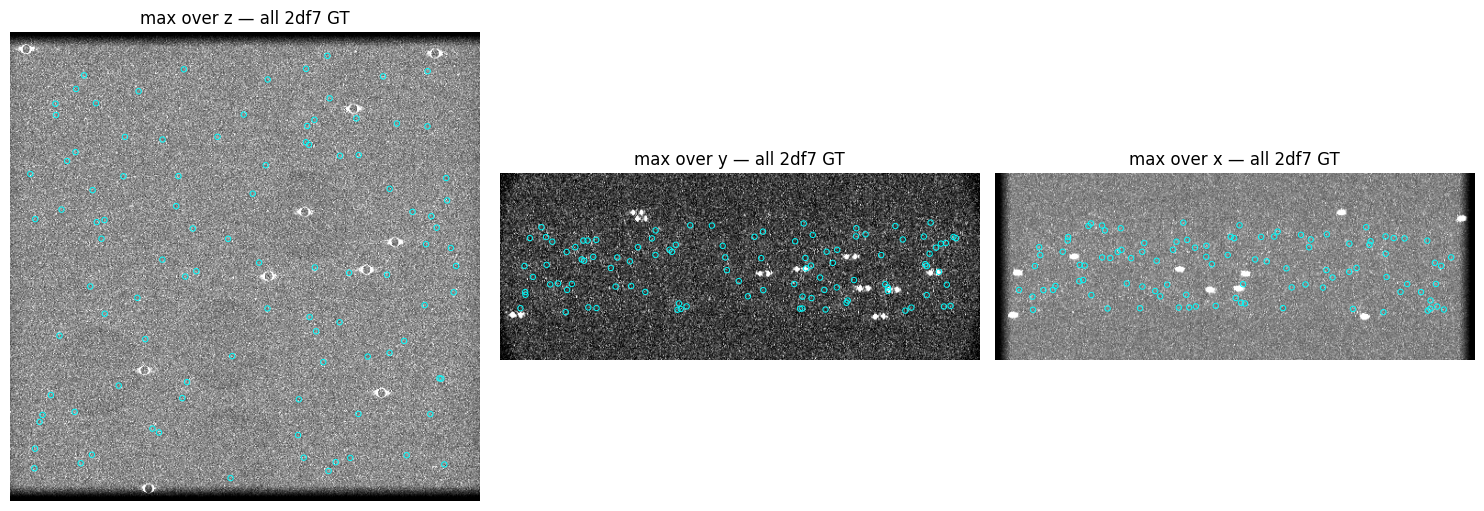

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
projections = [
    (full_tomogram.max(axis=0), target_zyx[:, [2, 1]], "max over z", (2, 1)),
    (full_tomogram.max(axis=1), target_zyx[:, [2, 0]], "max over y", (2, 0)),
    (full_tomogram.max(axis=2), target_zyx[:, [1, 0]], "max over x", (1, 0)),
]
for ax, (image, points, title, _) in zip(axes, projections):
    lo, hi = np.percentile(image, [2, 99.5])
    ax.imshow(image, vmin=lo, vmax=hi)
    ax.scatter(points[:, 0], points[:, 1], s=15, facecolors="none",
               edgecolors="cyan", linewidths=0.7)
    ax.set_title(title + " — all 2df7 GT")
    ax.axis("off")
plt.tight_layout()

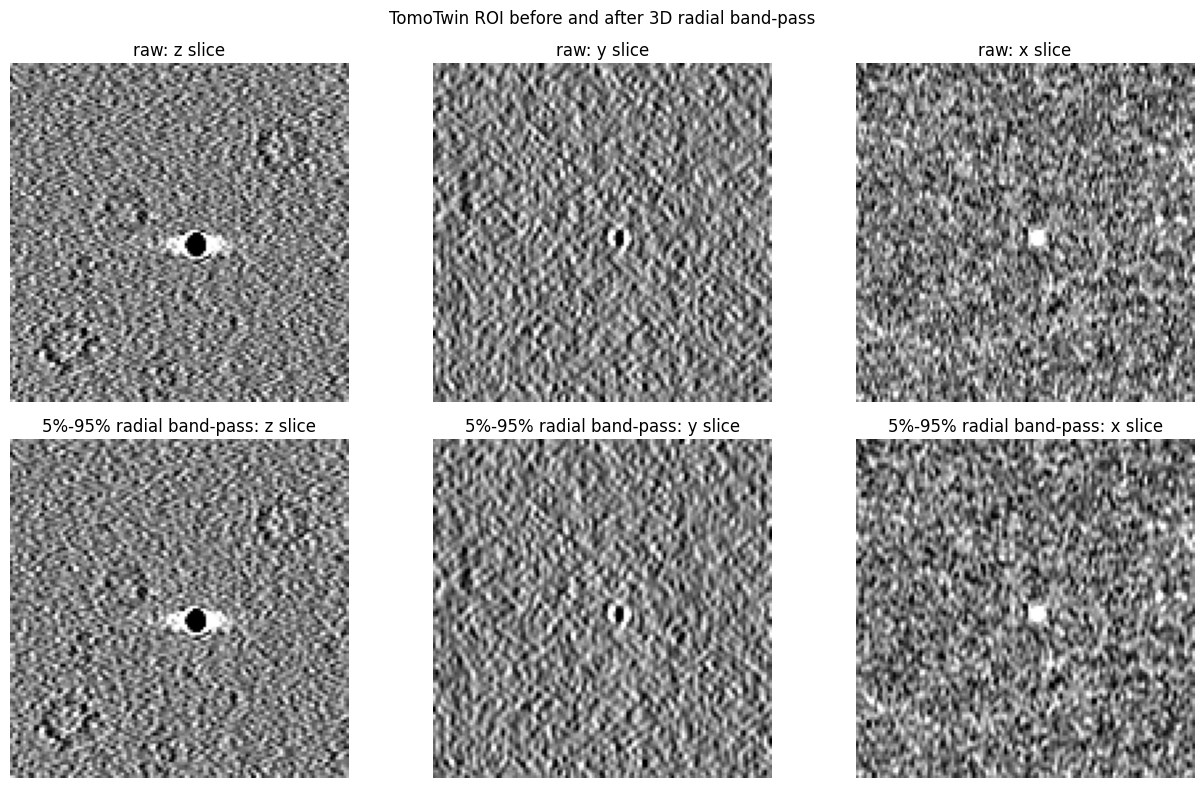

In [6]:
mid = ROI_SIZE // 2
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
raw_slices = [
    raw_tomogram[mid], raw_tomogram[:, mid], raw_tomogram[:, :, mid]
]
bandpassed_slices = [tomogram[mid], tomogram[:, mid], tomogram[:, :, mid]]
for column, title in enumerate(["z slice", "y slice", "x slice"]):
    for row, (image, stage) in enumerate([
        (raw_slices[column], "raw"),
        (bandpassed_slices[column], "5%-95% radial band-pass"),
    ]):
        lo, hi = np.percentile(image, [1, 99])
        axes[row, column].imshow(image, vmin=lo, vmax=hi)
        axes[row, column].set_title(f"{stage}: {title}")
        axes[row, column].axis("off")
plt.suptitle("TomoTwin ROI before and after 3D radial band-pass")
plt.tight_layout()

## Independent geometry and first-pass spectrum estimation

Following the 2D KLT paper, PSD patches use side `0.8D`, while the Fredholm
operator uses the independent support radius `a=0.2D`; the scoring-template
side is `2*ceil(a)+1`. Patches are extracted independently along all three
axes. This is important
for rectangular tomograms; using only `min(shape)` would discard most data.

In [7]:
def extract_nonoverlapping_patches(volume, patch_size):
    blocks = np.array(volume.shape) // patch_size
    cropped_shape = blocks * patch_size
    cropped = volume[
        :cropped_shape[0],
        :cropped_shape[1],
        :cropped_shape[2],
    ]
    bz, by, bx = blocks
    patches = cropped.reshape(
        bz, patch_size, by, patch_size, bx, patch_size
    ).transpose(0, 2, 4, 1, 3, 5)
    return patches.reshape(-1, patch_size, patch_size, patch_size), blocks

uniform_points, shell_ids, shell_counts = (
    generate_uniform_radial_sampling_points(SPECTRUM_SIZE, BANDLIMIT)
)

vect_spectrum_estimation = jax.vmap(
    estimate_isotropic_powerspectrum_tensor,
    in_axes=(0, None),
)
vect_radial_average = jax.vmap(
    radial_average_jax,
    in_axes=(0, None, None, None),
)

def estimate_and_calibrate(volume):
    patches, blocks = extract_nonoverlapping_patches(volume, PSD_PATCH_SIZE)
    centered = jnp.asarray(patches) - jnp.mean(
        jnp.asarray(patches), axis=(1, 2, 3), keepdims=True
    )
    variances = np.asarray(jnp.var(centered, axis=(1, 2, 3)))
    noise_count = max(1, int(np.floor(0.25 * variances.size)))
    noise_variance = float(np.mean(np.sort(variances)[:noise_count]))
    mean_variance = float(np.mean(variances))

    max_distance = int(np.floor(0.3 * PSD_PATCH_SIZE))
    psds = vect_spectrum_estimation(centered, max_distance)
    rblocks = vect_radial_average(
        psds, shell_ids, shell_counts, uniform_points.size
    )
    factorization = alternating_least_squares_solver(
        rblocks, ALS_MAX_ITER, 1e-4
    )
    particle_psd, noise_psd = calibrate_radial_psds(
        uniform_points,
        factorization.gamma,
        factorization.v,
        noise_variance,
        mean_variance,
    )
    return {
        "patches": np.asarray(patches),
        "blocks": blocks,
        "centered": centered,
        "variances": variances,
        "noise_variance": noise_variance,
        "mean_variance": mean_variance,
        "psds": np.asarray(psds),
        "rblocks": np.asarray(rblocks),
        "factorization": factorization,
        "particle_psd": particle_psd,
        "noise_psd": noise_psd,
    }

start = time.perf_counter()
first = estimate_and_calibrate(tomogram)
print(f"First PSD pass: {time.perf_counter() - start:.2f} s")
print("Patch blocks:", first["blocks"], "number of patches:", len(first["patches"]))
print("Noise variance:", first["noise_variance"])
print("Mean patch variance:", first["mean_variance"])

First PSD pass: 4.04 s
Patch blocks: [5 5 5] number of patches: 125
Noise variance: 0.7957612872123718
Mean patch variance: 0.8699811697006226


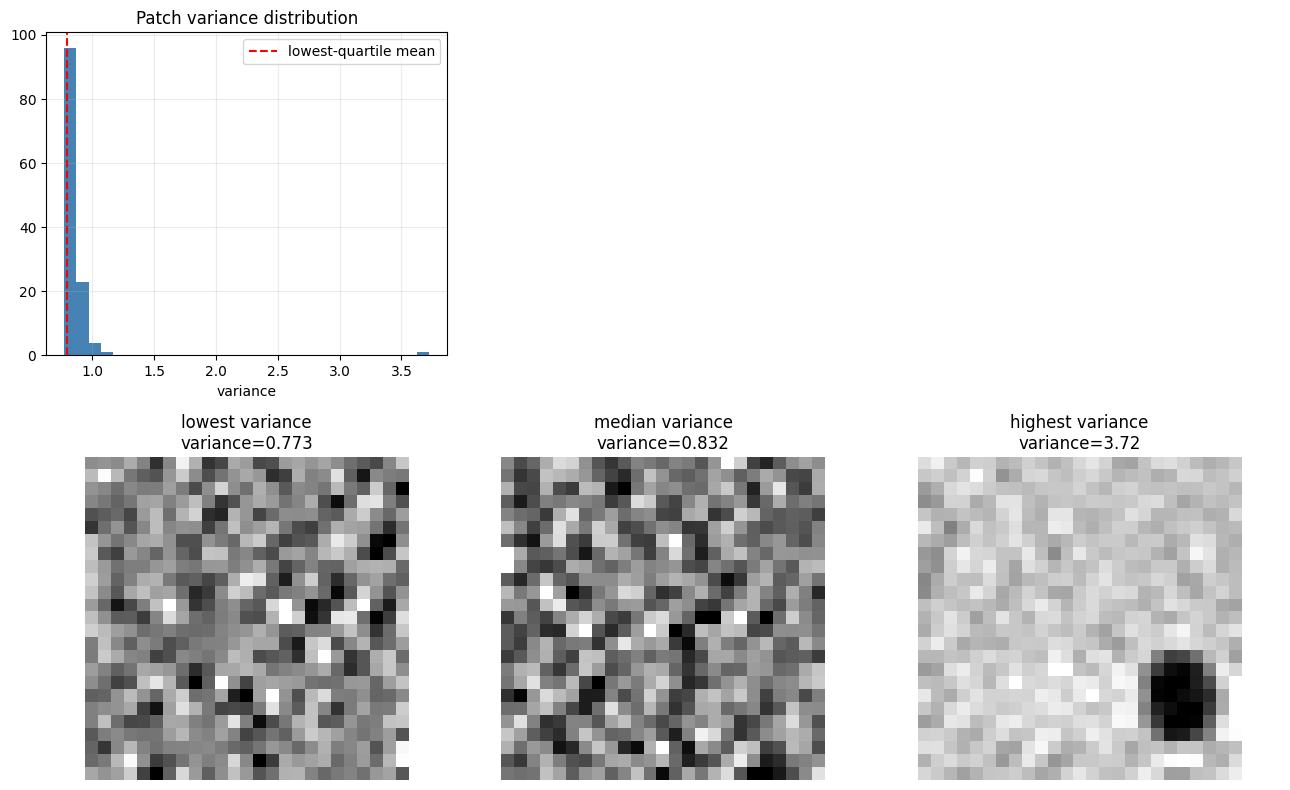

In [8]:
order = np.argsort(first["variances"])
chosen = [order[0], order[len(order)//2], order[-1]]
labels = ["lowest variance", "median variance", "highest variance"]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes[0, 0].hist(first["variances"], bins=30, color="steelblue")
axes[0, 0].axvline(first["noise_variance"], color="red", ls="--",
                   label="lowest-quartile mean")
axes[0, 0].set_title("Patch variance distribution")
axes[0, 0].legend()
axes[0, 0].set_xlabel("variance")
for col, (idx, label) in enumerate(zip(chosen, labels)):
    patch = first["patches"][idx]
    image = patch[PSD_PATCH_SIZE // 2]
    lo, hi = np.percentile(image, [1, 99])
    axes[1, col].imshow(image, vmin=lo, vmax=hi)
    axes[1, col].set_title(f"{label}\nvariance={first['variances'][idx]:.3g}")
    axes[1, col].axis("off")
for ax in axes[0, 1:]:
    ax.axis("off")
plt.tight_layout()

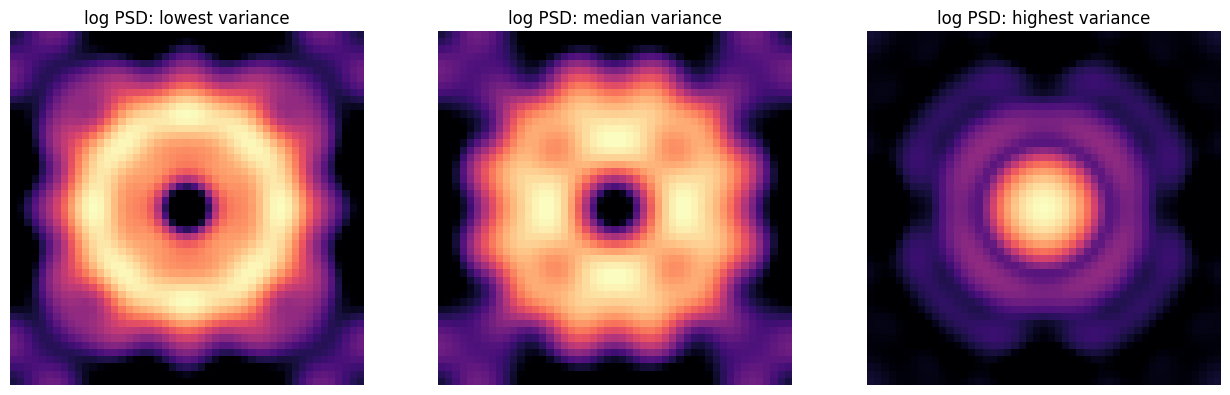

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
psd_mid = SPECTRUM_SIZE // 2
for ax, idx, label in zip(axes, chosen, labels):
    image = np.log1p(first["psds"][idx, psd_mid])
    ax.imshow(image, cmap="magma")
    ax.set_title(f"log PSD: {label}")
    ax.axis("off")
plt.tight_layout()

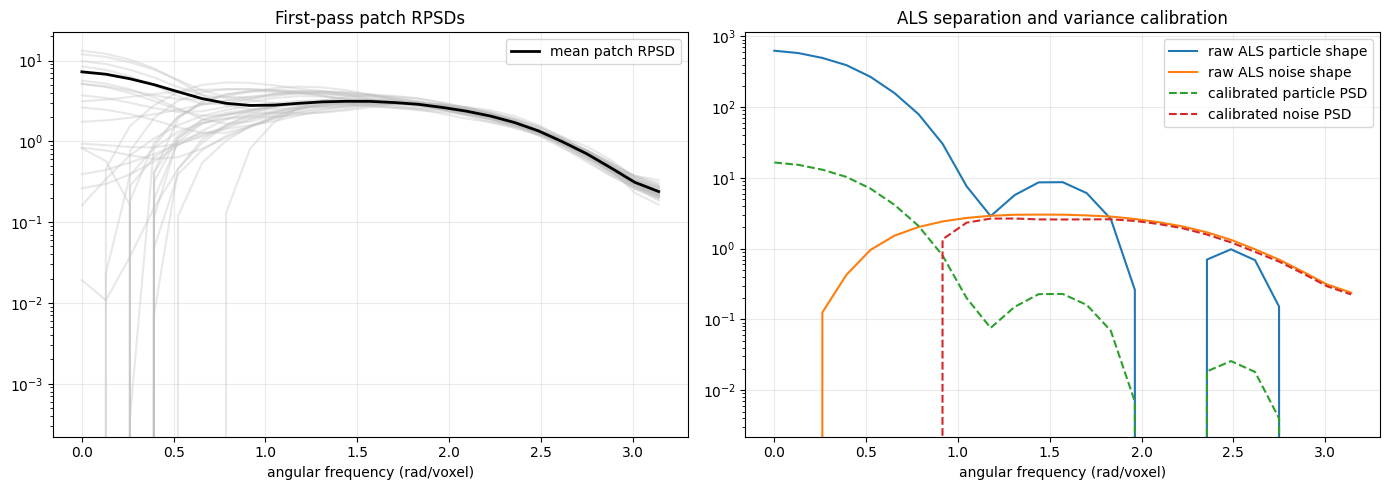

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for curve in first["rblocks"][::max(1, len(first["rblocks"]) // 30)]:
    axes[0].plot(uniform_points, curve, color="0.75", alpha=0.35)
axes[0].plot(uniform_points, first["rblocks"].mean(axis=0),
             color="black", lw=2, label="mean patch RPSD")
axes[0].set_yscale("log")
axes[0].set_title("First-pass patch RPSDs")
axes[0].set_xlabel("angular frequency (rad/voxel)")
axes[0].legend()

axes[1].plot(uniform_points, np.asarray(first["factorization"].gamma),
             label="raw ALS particle shape")
axes[1].plot(uniform_points, np.asarray(first["factorization"].v),
             label="raw ALS noise shape")
axes[1].plot(uniform_points, first["particle_psd"], "--",
             label="calibrated particle PSD")
axes[1].plot(uniform_points, first["noise_psd"], "--",
             label="calibrated noise PSD")
axes[1].set_yscale("log")
axes[1].set_title("ALS separation and variance calibration")
axes[1].set_xlabel("angular frequency (rad/voxel)")
axes[1].legend()
plt.tight_layout()

In [11]:
print("Integrated calibrated particle variance:",
      radial_psd_to_variance(uniform_points, first["particle_psd"]))
print("Measured signal variance:",
      first["mean_variance"] - first["noise_variance"])
print("Integrated calibrated noise variance:",
      radial_psd_to_variance(uniform_points, first["noise_psd"]))
print("Measured noise variance:", first["noise_variance"])

Integrated calibrated particle variance: 0.07421988248825073
Measured signal variance: 0.07421988248825073
Integrated calibrated noise variance: 0.7957612872123717
Measured noise variance: 0.7957612872123718


## Prewhitening and second-pass spectrum estimation

In [12]:
start = time.perf_counter()
whitened = prewhiten_tomogram(
    jnp.asarray(tomogram),
    uniform_points,
    first["noise_psd"],
)
jax.block_until_ready(whitened)
whitened_np = np.asarray(whitened)
print(f"Whitening: {time.perf_counter() - start:.2f} s")
print("Whitened mean/norm:", whitened_np.mean(), np.linalg.norm(whitened_np))

Whitening: 0.34 s
Whitened mean/norm: -3.4461323e-13 1.0


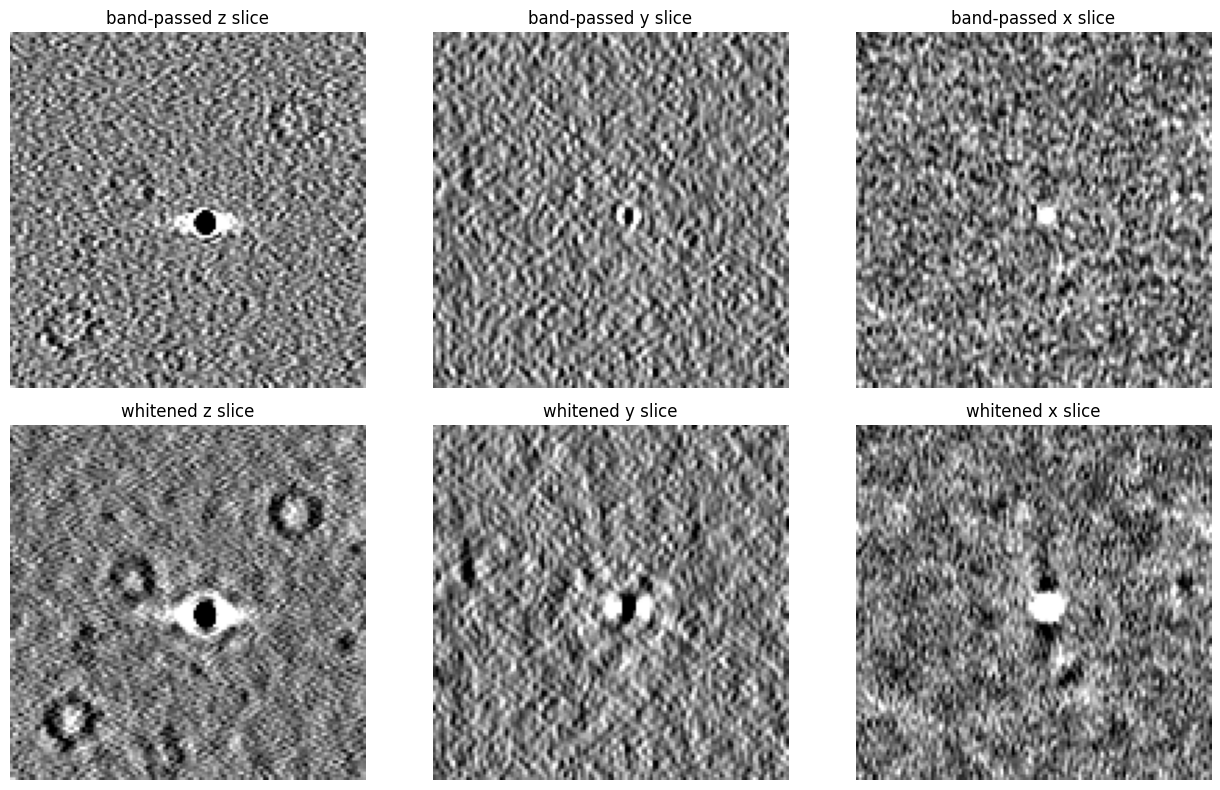

In [13]:
def robust_standardize(image):
    lo, hi = np.percentile(image, [1, 99])
    return np.clip((image - lo) / (hi - lo + 1e-12), 0, 1)

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
filtered_slices = [tomogram[mid], tomogram[:, mid], tomogram[:, :, mid]]
white_slices = [whitened_np[mid], whitened_np[:, mid], whitened_np[:, :, mid]]
titles = ["z", "y", "x"]
for col in range(3):
    axes[0, col].imshow(robust_standardize(filtered_slices[col]))
    axes[0, col].set_title(f"band-passed {titles[col]} slice")
    axes[1, col].imshow(robust_standardize(white_slices[col]))
    axes[1, col].set_title(f"whitened {titles[col]} slice")
    axes[0, col].axis("off")
    axes[1, col].axis("off")
plt.tight_layout()

In [14]:
start = time.perf_counter()
second = estimate_and_calibrate(whitened_np)
print(f"Second PSD pass: {time.perf_counter() - start:.2f} s")
print("Second-pass noise variance:", second["noise_variance"])

Second PSD pass: 0.41 s
Second-pass noise variance: 3.516138917802891e-07


Noise PSD coefficient of variation before: 0.8651982244723997
Noise PSD coefficient of variation after: 1.0362833594781642
DIAGNOSTIC WARNING: the second-pass ALS noise estimate is not flatter. Whitening executed numerically, but the isotropic noise model or ALS separation should be investigated on this realistic tomogram.


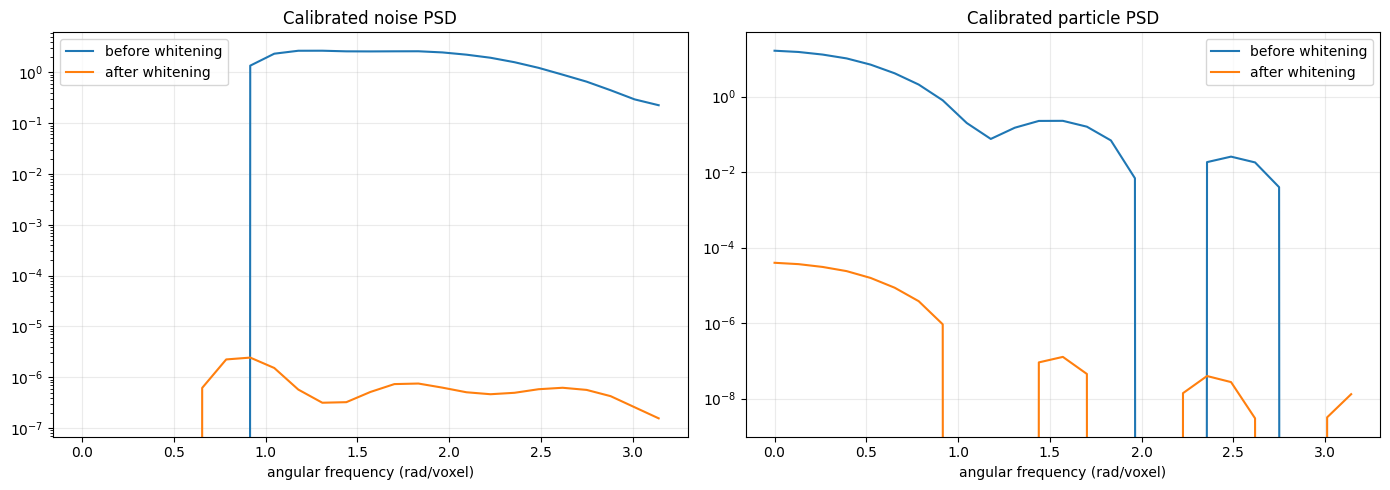

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(uniform_points, first["noise_psd"], label="before whitening")
axes[0].plot(uniform_points, second["noise_psd"], label="after whitening")
axes[0].set_yscale("log")
axes[0].set_title("Calibrated noise PSD")
axes[0].set_xlabel("angular frequency (rad/voxel)")
axes[0].legend()

axes[1].plot(uniform_points, first["particle_psd"], label="before whitening")
axes[1].plot(uniform_points, second["particle_psd"], label="after whitening")
axes[1].set_yscale("log")
axes[1].set_title("Calibrated particle PSD")
axes[1].set_xlabel("angular frequency (rad/voxel)")
axes[1].legend()
plt.tight_layout()

noise_flatness_before = np.std(first["noise_psd"]) / np.mean(first["noise_psd"])
noise_flatness_after = np.std(second["noise_psd"]) / np.mean(second["noise_psd"])
print("Noise PSD coefficient of variation before:", noise_flatness_before)
print("Noise PSD coefficient of variation after:", noise_flatness_after)
if noise_flatness_after >= noise_flatness_before:
    print(
        "DIAGNOSTIC WARNING: the second-pass ALS noise estimate is not flatter. "
        "Whitening executed numerically, but the isotropic noise model or ALS "
        "separation should be investigated on this realistic tomogram."
    )

## Fredholm equations across angular orders

Each eigenvalue is indexed by angular degree `ell` and radial index `n`.
Under isotropy it is independent of spherical-harmonic `m`, producing a
`(2 ell + 1)`-fold multiplet.

In [16]:
legendre_nodes, legendre_weights = scipy.special.roots_legendre(LEGENDRE_ORDER)
frequency_nodes = BANDLIMIT * (legendre_nodes + 1) / 2
Gx = np.maximum(
    np.asarray(
        trigonometric_interpolation(
            uniform_points,
            second["particle_psd"],
            frequency_nodes,
        )
    ),
    0,
)

eigvals_by_order = []
eigfuncs_by_order = []
quadrature_by_order = []
for ell in range(MAX_ANGULAR_ORDER):
    values, functions, W = solve_radial_fredholm_equation(
        Gx,
        ell,
        FREDHOLM_RADIUS,
        BANDLIMIT,
        K=LEGENDRE_ORDER,
    )
    eigvals_by_order.append(values)
    eigfuncs_by_order.append(functions)
    quadrature_by_order.append(W)

eigvals_matrix = np.asarray(eigvals_by_order)
eigfuncs_matrix = np.asarray(eigfuncs_by_order)

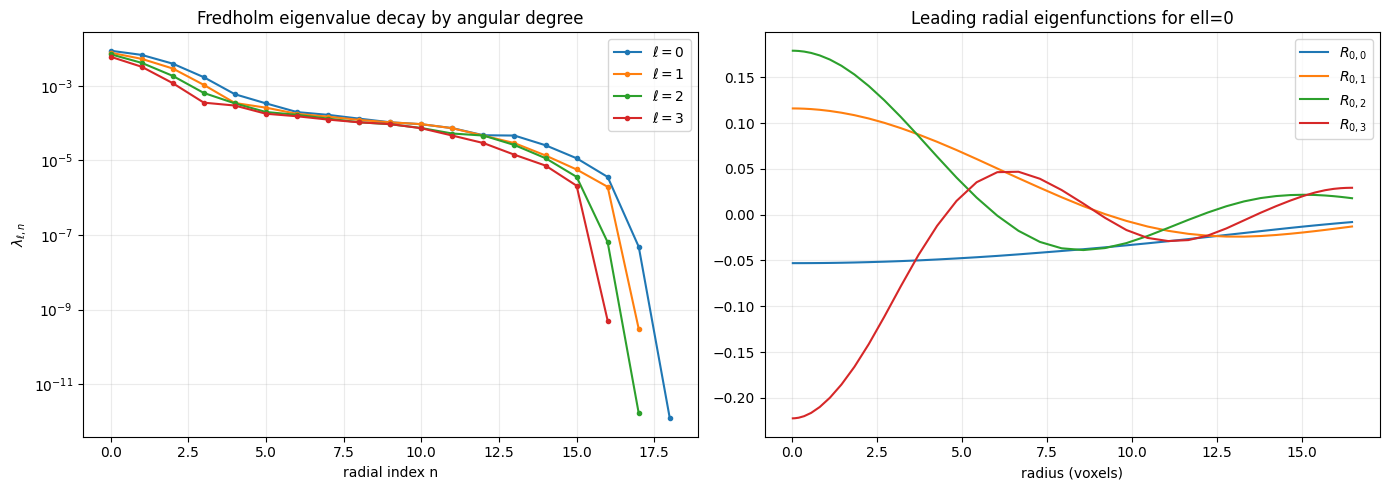

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ell in range(MAX_ANGULAR_ORDER):
    positive = eigvals_matrix[ell] > 0
    axes[0].semilogy(
        np.arange(LEGENDRE_ORDER)[positive],
        eigvals_matrix[ell, positive],
        marker=".",
        label=fr"$\ell={ell}$",
    )
axes[0].set_title("Fredholm eigenvalue decay by angular degree")
axes[0].set_xlabel("radial index n")
axes[0].set_ylabel(r"$\lambda_{\ell,n}$")
axes[0].legend()

spatial_nodes = FREDHOLM_RADIUS * (legendre_nodes + 1) / 2
for n in range(min(4, LEGENDRE_ORDER)):
    axes[1].plot(
        spatial_nodes,
        np.real(eigfuncs_matrix[0, :, n]),
        label=fr"$R_{{0,{n}}}$",
    )
axes[1].set_title("Leading radial eigenfunctions for ell=0")
axes[1].set_xlabel("radius (voxels)")
axes[1].legend()
plt.tight_layout()

In [18]:
flat_eigvals = eigvals_matrix.reshape(-1)
flat_eigfuncs = eigfuncs_matrix.transpose(0, 2, 1).reshape(-1, LEGENDRE_ORDER)
flat_orders = np.repeat(np.arange(MAX_ANGULAR_ORDER), LEGENDRE_ORDER)
flat_radial_indices = np.tile(np.arange(LEGENDRE_ORDER), MAX_ANGULAR_ORDER)

sort_idx = np.argsort(flat_eigvals)[::-1]
flat_eigvals = flat_eigvals[sort_idx]
flat_eigfuncs = flat_eigfuncs[sort_idx]
flat_orders = flat_orders[sort_idx]
flat_radial_indices = flat_radial_indices[sort_idx]

positive = flat_eigvals > np.spacing(1)
flat_eigvals = flat_eigvals[positive]
flat_eigfuncs = flat_eigfuncs[positive]
flat_orders = flat_orders[positive]
flat_radial_indices = flat_radial_indices[positive]

assert np.all(np.diff(flat_eigvals) <= 0)
display(pd.DataFrame({
    "lambda": flat_eigvals[:20],
    "ell": flat_orders[:20],
    "radial_n": flat_radial_indices[:20],
    "m_multiplicity": 2 * flat_orders[:20] + 1,
}))

,lambda,ell,radial_n,m_multiplicity
0,0.008683,0,0,1
1,0.007678,1,0,3
2,0.006978,2,0,5
3,0.006706,0,1,1
4,0.005985,3,0,7
5,0.005254,1,1,3
6,0.004107,2,1,5
7,0.003907,0,2,1
8,0.003226,3,1,7
9,0.002898,1,2,3


## Interpolate radial eigenfunctions and construct complete templates

The radial Fredholm eigenfunctions live on `0 <= r <= a`. They are embedded
in the independently configured cubic template grid and explicitly set to
zero outside the radius-`a` ball.

In [19]:
truncate_idx = radial_mode_truncation_index(
    flat_eigvals,
    flat_orders,
    ENERGY_FRACTION,
)
eigvals = flat_eigvals[:truncate_idx]
eigfuncs = flat_eigfuncs[:truncate_idx]
orders = flat_orders[:truncate_idx]
radial_indices = flat_radial_indices[:truncate_idx]

radius_grid = np.arange(-(TEMPLATE_SIDE // 2), TEMPLATE_SIDE // 2 + 1)
Z, Y, X = np.meshgrid(radius_grid, radius_grid, radius_grid, indexing="ij")
r_tensor = np.sqrt(Z**2 + Y**2 + X**2)
template_support = r_tensor <= FREDHOLM_RADIUS
rho_uniform, rho_inverse = np.unique(
    r_tensor[template_support],
    return_inverse=True,
)

rho_leg_a = FREDHOLM_RADIUS * (legendre_nodes + 1) / 2
rho_leg_c = BANDLIMIT * (legendre_nodes + 1) / 2
r_grid_uniform = np.outer(rho_uniform, rho_leg_c)
r_grid_legendre = np.outer(rho_leg_a, rho_leg_c)

def Hn(values, ell):
    return 4 * np.pi * (1j**ell) * scipy.special.spherical_jn(ell, values)

max_retained_order = int(orders.max()) + 1
H_uniform = np.asarray([
    Hn(r_grid_uniform, ell) for ell in range(max_retained_order)
])[orders]
H_legendre = np.asarray([
    Hn(r_grid_legendre, ell) for ell in range(max_retained_order)
])[orders]

frequency_measure = (
    BANDLIMIT / 2
    * legendre_weights
    * Gx
    * rho_leg_c**2
)
spatial_measure = (
    FREDHOLM_RADIUS / 2
    * legendre_weights
    * rho_leg_a**2
)
sign = np.where(orders % 2, -1, 1)
psi = (
    H_uniform * frequency_measure[None, None, :]
) @ (sign[:, None, None] * H_legendre)

eigfuncs_uniform = (
    np.einsum("bik,k,bk->bi", psi, spatial_measure, eigfuncs)
    / eigvals[:, None]
)
radial_templates = np.zeros(
    (len(eigvals), TEMPLATE_SIDE, TEMPLATE_SIDE, TEMPLATE_SIDE),
    dtype=eigfuncs_uniform.dtype,
)
radial_templates[:, template_support] = eigfuncs_uniform[:, rho_inverse]

templates, template_radial_index, m_values = (
    expand_spherical_harmonic_templates(
        radial_templates,
        orders,
        Z,
        Y,
        X,
    )
)
template_eigvals = eigvals[template_radial_index]
template_orders = orders[template_radial_index]

print("Retained radial eigenpairs:", len(eigvals))
print("Expanded angular templates:", len(templates))
print("Orders/counts:", np.unique(template_orders, return_counts=True))

Retained radial eigenpairs: 45
Expanded angular templates: 177
Orders/counts: (array([0, 1, 2, 3]), array([12, 33, 55, 77]))


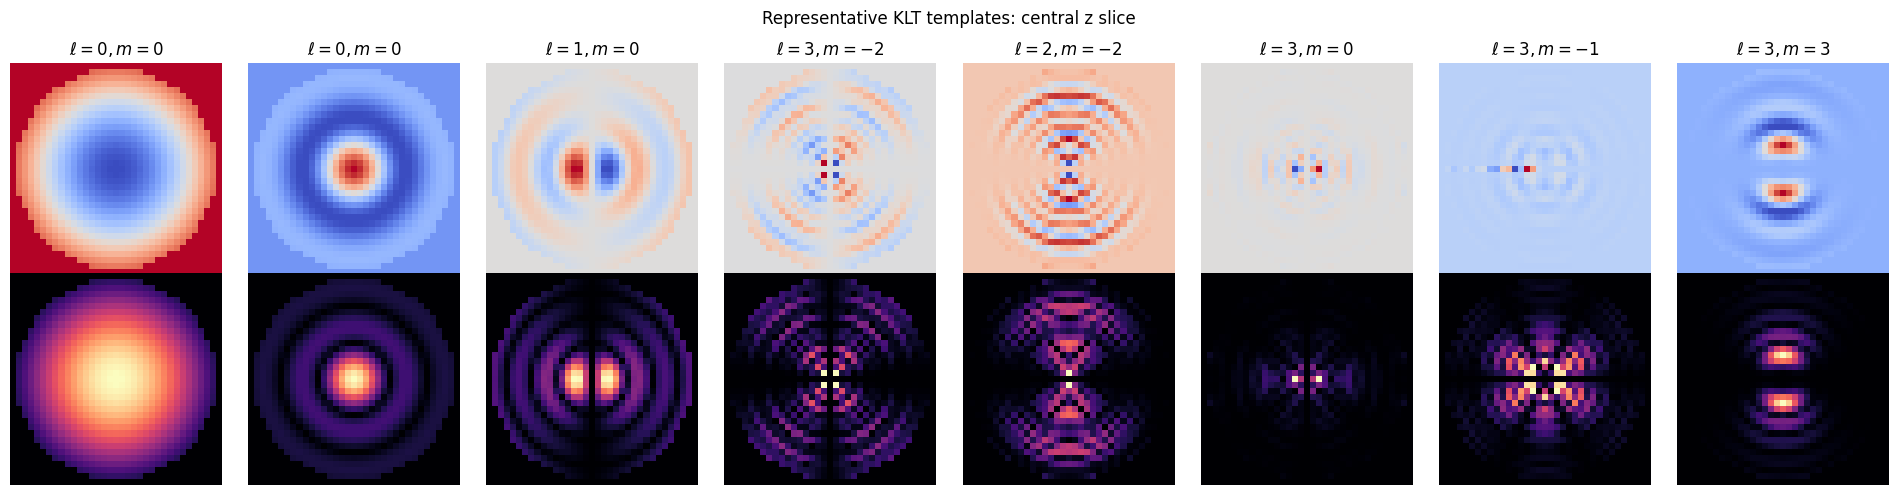

In [20]:
show = np.linspace(0, len(templates) - 1, min(8, len(templates))).astype(int)
fig, axes = plt.subplots(2, len(show), figsize=(2.4 * len(show), 5))
for col, template_idx in enumerate(show):
    center_slice = templates[template_idx, TEMPLATE_SIDE // 2]
    axes[0, col].imshow(np.real(center_slice), cmap="coolwarm")
    axes[0, col].set_title(
        fr"$\ell={template_orders[template_idx]},m={m_values[template_idx]}$"
    )
    axes[1, col].imshow(np.abs(center_slice), cmap="magma")
    axes[0, col].axis("off")
    axes[1, col].axis("off")
axes[0, 0].set_ylabel("real")
axes[1, 0].set_ylabel("magnitude")
plt.suptitle("Representative KLT templates: central z slice")
plt.tight_layout()

## Likelihood score volume

We now construct the low-rank covariance in the template span and correlate
each resulting likelihood kernel with the same whitened volume used for the
second PSD estimate.

In [21]:
n_templates = templates.shape[0]
template_voxels = TEMPLATE_SIDE**3
template_matrix = jnp.asarray(templates.reshape(n_templates, template_voxels).T)
Q, R = jnp.linalg.qr(template_matrix, mode="reduced")

noise_variance = second["noise_variance"]
H = (
    (R * jnp.asarray(template_eigvals)[None, :]) @ jnp.conj(R.T)
    + noise_variance * jnp.eye(R.shape[0])
)
H_eigvals, P = jnp.linalg.eigh(H)
D = (1 / noise_variance) - (1 / H_eigvals)
mu = jnp.linalg.slogdet(H / noise_variance)[1]

D = D[::-1]
P = P[:, ::-1]
B = Q @ P
kernels = B.T.reshape(-1, TEMPLATE_SIDE, TEMPLATE_SIDE, TEMPLATE_SIDE)

score_shape = tuple(np.array(tomogram.shape) - TEMPLATE_SIDE + 1)
score_init = jnp.zeros(score_shape, dtype=jnp.float32)

def score_body(i, score):
    kernel = jnp.conj(jnp.flip(kernels[i], axis=(0, 1, 2)))
    response = jax.scipy.signal.fftconvolve(
        whitened,
        kernel,
        mode="valid",
    )
    return score + D[i] * jnp.abs(response)**2

start = time.perf_counter()
score = jax.lax.fori_loop(0, kernels.shape[0], score_body, score_init) - mu
score_np = np.asarray(score)
print(f"Likelihood scoring: {time.perf_counter() - start:.2f} s")
print("Score shape:", score_np.shape)
print("Score min/max:", score_np.min(), score_np.max())
assert np.isfinite(score_np).all()

Likelihood scoring: 5.89 s
Score shape: (94, 94, 94)
Score min/max: -756.762 422941.4


<Axes: title={'center': 'Likelihood-score distribution'}, xlabel='Likelihood score', ylabel='Number of voxels'>

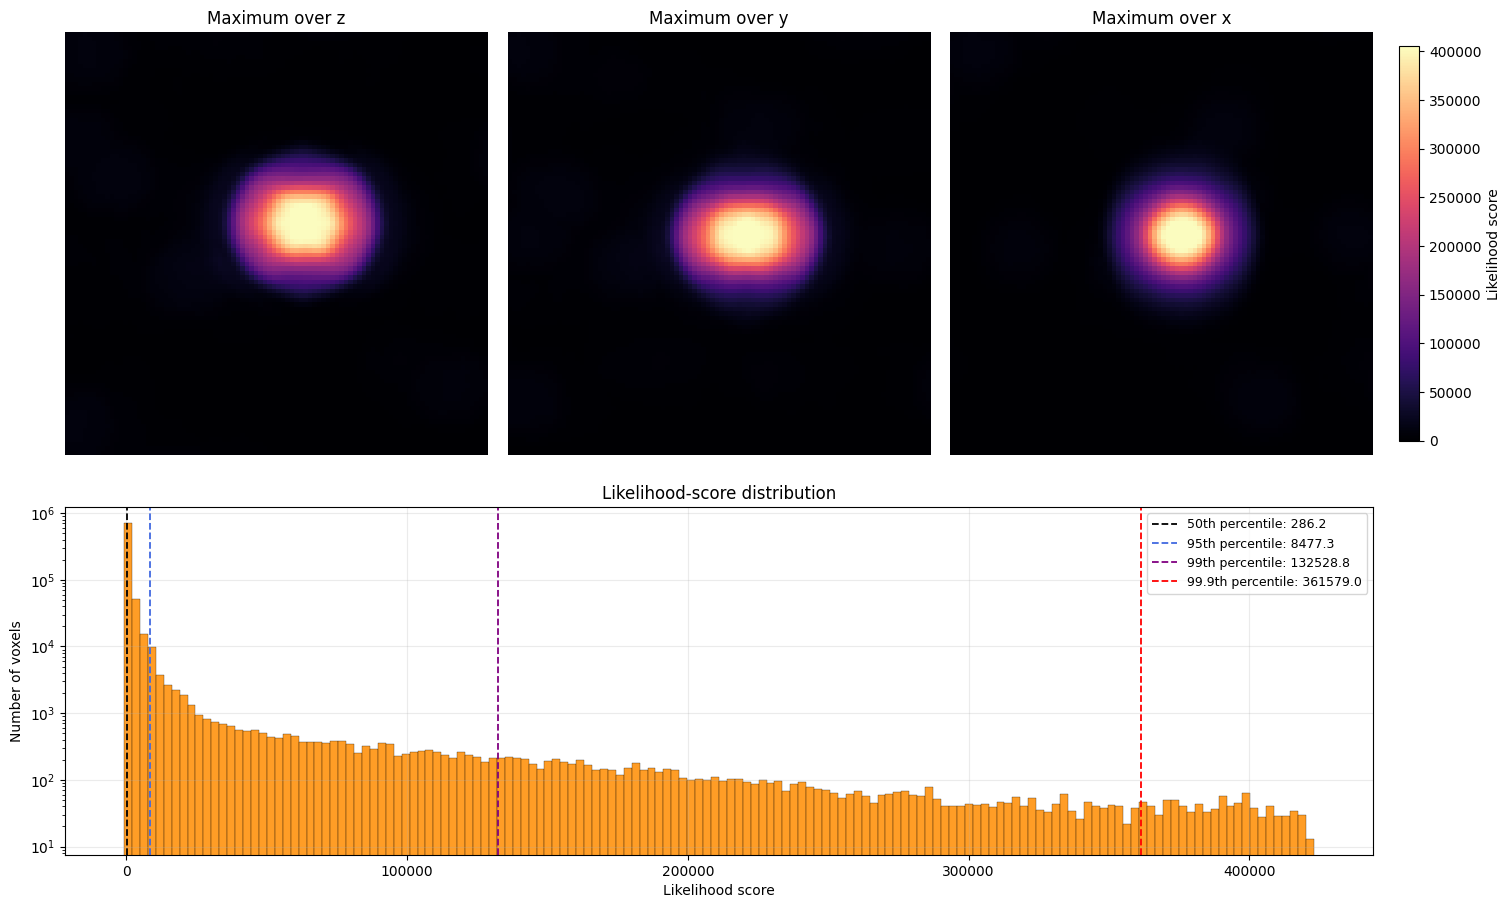

In [22]:
score_projections = [
    score_np.max(axis=0),
    score_np.max(axis=1),
    score_np.max(axis=2),
]
projection_titles = [
    "Maximum over z",
    "Maximum over y",
    "Maximum over x",
]

fig = plt.figure(figsize=(15, 9), constrained_layout=True)
grid = fig.add_gridspec(
    nrows=2,
    ncols=3,
    height_ratios=[1.0, 0.75],
)

projection_axes = [
    fig.add_subplot(grid[0, column])
    for column in range(3)
]
histogram_axis = fig.add_subplot(grid[1, :])

# Use a common color scale so the three projections are comparable.
display_min = min(np.percentile(image, 1) for image in score_projections)
display_max = max(np.percentile(image, 99.5) for image in score_projections)

for axis, image, title in zip(
    projection_axes,
    score_projections,
    projection_titles,
):
    plotted_image = axis.imshow(
        image,
        cmap="magma",
        vmin=display_min,
        vmax=display_max,
        origin="lower",
    )
    axis.set_title(title, fontsize=12)
    axis.axis("off")

# One colorbar shared by all three projections.
colorbar = fig.colorbar(
    plotted_image,
    ax=projection_axes,
    location="right",
    shrink=0.85,
    pad=0.02,
)
colorbar.set_label("Likelihood score")

# Score distribution.
flat_scores = score_np.ravel()
histogram_axis.hist(
    flat_scores,
    bins=150,
    color="darkorange",
    edgecolor="black",
    linewidth=0.25,
    alpha=0.85,
)
histogram_axis.set_yscale("log")
histogram_axis.set_title("Likelihood-score distribution")
histogram_axis.set_xlabel("Likelihood score")
histogram_axis.set_ylabel("Number of voxels")

# Mark useful reference percentiles.
for percentile, color in zip(
    [50, 95, 99, 99.9],
    ["black", "royalblue", "purple", "red"],
):
    value = np.percentile(flat_scores, percentile)
    histogram_axis.axvline(
        value,
        color=color,
        linestyle="--",
        linewidth=1.3,
        label=f"{percentile:g}th percentile: {value:.1f}",
    )

histogram_axis.legend(fontsize=9)
histogram_axis

## Known-count NMS: recall at the true particle count

For this first localization diagnostic, assume the number of evaluable particles is known a priori. NMS therefore returns exactly the top `KNOWN_PARTICLE_COUNT` spatially separated responses. This tests whether the true particles occur among the highest-ranked responses; it does not yet test an autonomous score threshold.

In [23]:
def nms_ranked(score_volume, radius, max_picks):
    candidate_indices, candidate_values = ranked_local_maxima_nms_3d(
        score_volume,
        radius=radius,
        max_picks=max_picks,
    )
    centers = candidate_indices + TEMPLATE_SIDE // 2
    return np.column_stack((centers, candidate_values))

picks = nms_ranked(
    score_np,
    radius=PARTICLE_DIAMETER_VOXELS,
    max_picks=KNOWN_PARTICLE_COUNT,
)
assert len(picks) == KNOWN_PARTICLE_COUNT
print(f"Known-count diagnostic: retained the top {len(picks)} NMS picks")
display(pd.DataFrame(picks, columns=["z", "y", "x", "score"]))

Known-count diagnostic: retained the top 7 NMS picks


,z,y,x,score
0,66.0,70.0,70.0,422941.406250
1,76.0,78.0,27.0,10616.735352
2,106.0,21.0,19.0,10173.507812
3,65.0,109.0,21.0,9874.733398
4,27.0,84.0,19.0,9323.142578
5,61.0,30.0,102.0,8301.601562
6,31.0,82.0,110.0,6949.738770


In [24]:
def known_count_assignment(predicted, ground_truth, tolerance):
    """Maximize matches within tolerance, then minimize their distances."""
    distances = cdist(predicted[:, :3], ground_truth)
    # An out-of-tolerance assignment must cost more than every possible set
    # of valid assignments, so Hungarian matching first maximizes recall.
    invalid_cost = (max(len(predicted), len(ground_truth)) + 1) * (tolerance + 1)
    matching_cost = np.where(distances <= tolerance, distances, invalid_cost)
    pred_idx, gt_idx = linear_sum_assignment(matching_cost)
    assigned_distances = distances[pred_idx, gt_idx]
    matched = assigned_distances <= tolerance

    table = pd.DataFrame({
        "pick_rank": pred_idx + 1,
        "gt_index": gt_idx + 1,
        "score": predicted[pred_idx, 3],
        "pick_z": predicted[pred_idx, 0],
        "pick_y": predicted[pred_idx, 1],
        "pick_x": predicted[pred_idx, 2],
        "gt_z": ground_truth[gt_idx, 0],
        "gt_y": ground_truth[gt_idx, 1],
        "gt_x": ground_truth[gt_idx, 2],
        "distance_voxels": assigned_distances,
        "distance_in_D": assigned_distances / PARTICLE_DIAMETER_VOXELS,
        "picked": matched,
    }).sort_values("pick_rank").reset_index(drop=True)
    return table

assignment = known_count_assignment(picks, gt, MATCH_TOLERANCE)
num_recovered = int(assignment["picked"].sum())
recall_at_known_count = num_recovered / KNOWN_PARTICLE_COUNT
matched_distances = assignment.loc[assignment["picked"], "distance_voxels"]

summary = pd.Series({
    "known particle count": KNOWN_PARTICLE_COUNT,
    "particles recovered": num_recovered,
    "particles missed": KNOWN_PARTICLE_COUNT - num_recovered,
    "recall at known count": recall_at_known_count,
    "matching tolerance (voxels)": MATCH_TOLERANCE,
    "mean matched distance (voxels)": matched_distances.mean(),
    "maximum matched distance (voxels)": matched_distances.max(),
})
display(summary.to_frame("known-count localization result"))
display(assignment.style.format({
    "score": "{:.3f}",
    "distance_voxels": "{:.2f}",
    "distance_in_D": "{:.3f}",
}))

,known-count localization result
known particle count,7.000000
particles recovered,5.000000
particles missed,2.000000
recall at known count,0.714286
matching tolerance (voxels),16.500000
mean matched distance (voxels),3.047174
maximum matched distance (voxels),3.632852


,pick_rank,gt_index,score,pick_z,pick_y,pick_x,gt_z,gt_y,gt_x,distance_voxels,distance_in_D,picked
0,1,3,422941.406,66.000000,70.000000,70.000000,59.880879,56.072757,44.277719,29.88,0.906,False
1,2,6,10616.735,76.000000,78.000000,27.000000,74.620440,79.536170,27.658604,2.17,0.066,True
2,3,1,10173.508,106.000000,21.000000,19.000000,107.731569,23.868912,18.579984,3.38,0.102,True
3,4,7,9874.733,65.000000,109.000000,21.000000,66.519936,106.812956,21.737552,2.76,0.084,True
4,5,2,9323.143,27.000000,84.000000,19.000000,29.689009,86.287265,19.857473,3.63,0.110,True
5,6,4,8301.602,61.000000,30.000000,102.000000,63.434962,32.157433,102.523283,3.30,0.100,True
6,7,5,6949.739,31.000000,82.000000,110.000000,90.085572,78.010331,73.486220,69.57,2.108,False


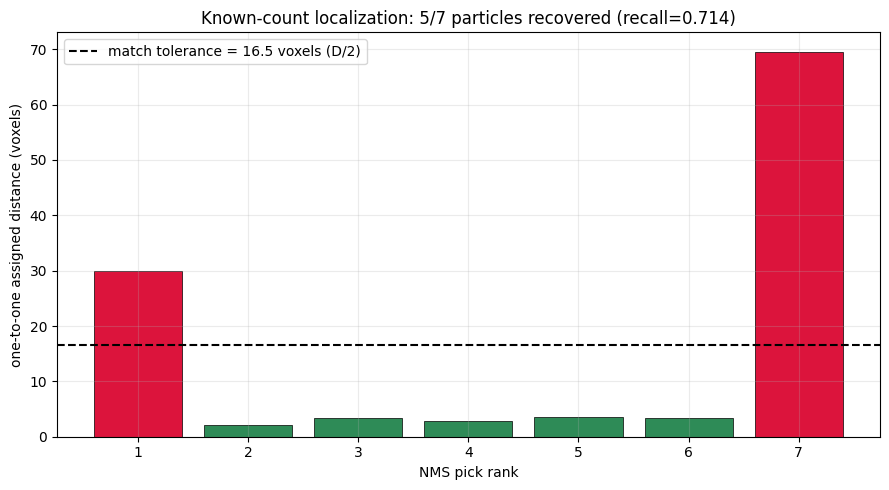

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = np.where(assignment["picked"], "seagreen", "crimson")
ax.bar(
    assignment["pick_rank"],
    assignment["distance_voxels"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.5,
)
ax.axhline(
    MATCH_TOLERANCE,
    color="black",
    linestyle="--",
    label=f"match tolerance = {MATCH_TOLERANCE:.1f} voxels (D/2)",
)
ax.set_xticks(assignment["pick_rank"])
ax.set_xlabel("NMS pick rank")
ax.set_ylabel("one-to-one assigned distance (voxels)")
ax.set_title(
    f"Known-count localization: {num_recovered}/{KNOWN_PARTICLE_COUNT} particles recovered "
    f"(recall={recall_at_known_count:.3f})"
)
ax.legend()
plt.tight_layout()

## NMS-radius recall sweep on the fixed score tensor

Reuse the already-computed likelihood tensor and rerun only spherical NMS. The only changed parameter is the suppression radius. For each radius, retain the known number of particles and report recall. Here `D` is the configured 33-voxel particle diameter; the values below are **NMS radii**, not full suppression-sphere diameters.

,NMS radius / D,NMS radius (voxels),particles recovered,recall
0,0.5,16.5,6,0.857
1,0.7,23.1,5,0.714
2,1.0,33.0,5,0.714


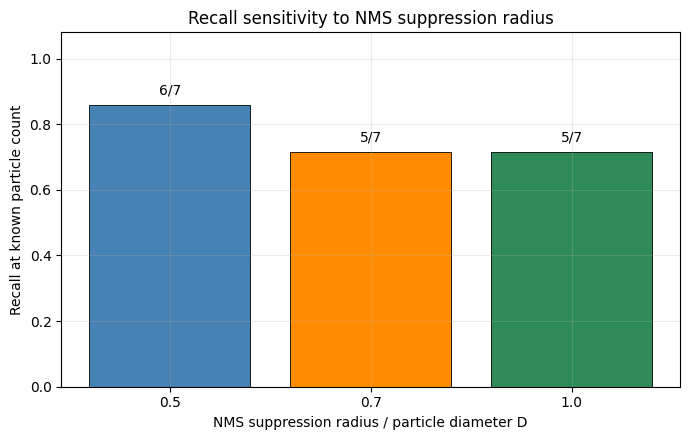

In [26]:
def recall_at_nms_radius(radius_factor):
    swept_picks = nms_ranked(
        score_np,
        radius=radius_factor * PARTICLE_DIAMETER_VOXELS,
        max_picks=KNOWN_PARTICLE_COUNT,
    )
    swept_assignment = known_count_assignment(
        swept_picks,
        gt,
        MATCH_TOLERANCE,
    )
    recovered = int(swept_assignment["picked"].sum())
    return recovered, recovered / KNOWN_PARTICLE_COUNT


nms_sweep_rows = []
for radius_factor in (0.5, 0.7, 1.0):
    recovered, recall = recall_at_nms_radius(radius_factor)
    nms_sweep_rows.append({
        "NMS radius / D": radius_factor,
        "NMS radius (voxels)": radius_factor * PARTICLE_DIAMETER_VOXELS,
        "particles recovered": recovered,
        "recall": recall,
    })

nms_sweep = pd.DataFrame(nms_sweep_rows)
display(nms_sweep.style.format({
    "NMS radius / D": "{:.1f}",
    "NMS radius (voxels)": "{:.1f}",
    "recall": "{:.3f}",
}))

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(
    nms_sweep["NMS radius / D"].astype(str),
    nms_sweep["recall"],
    color=["steelblue", "darkorange", "seagreen"],
    edgecolor="black",
    linewidth=0.6,
)
for bar, recovered in zip(bars, nms_sweep["particles recovered"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.025,
        f"{recovered}/{KNOWN_PARTICLE_COUNT}",
        ha="center",
        va="bottom",
    )
ax.set_ylim(0, 1.08)
ax.set_xlabel("NMS suppression radius / particle diameter D")
ax.set_ylabel("Recall at known particle count")
ax.set_title("Recall sensitivity to NMS suppression radius")
plt.tight_layout()

## Fredholm-support radius sweep with fixed picking settings

The NMS sweep above changes only post-processing of one fixed likelihood tensor; it cannot test whether the smaller Fredholm support caused the score degradation. Here we recompute the Fredholm eigenfunctions, spatial templates, covariance model, and full likelihood tensor for each support radius. The band-pass, PSD estimate, whitening, angular-order limit, energy cutoff, known-count top-7 evaluation, $D/2$ matching tolerance, and NMS radius of $1D$ are all fixed.

The `0.20D` setting is the paper-derived value. The `12 voxels` setting exactly recovers the earlier support radius (and therefore a 25-voxel template side), while the other values show the trend around it.

0.20D (paper): a=6.60, side=15, recovered=2/7


0.30D: a=9.90, side=21, recovered=3/7


12 vox (old): a=12.00, side=25, recovered=4/7


0.40D: a=13.20, side=29, recovered=5/7
0.50D: a=16.50, side=35, recovered=5/7


,setting,Fredholm radius / D,Fredholm radius (voxels),template side,radial eigenpairs,angular templates,particles recovered,recall,elapsed (s)
0,0.20D (paper),0.200,6.60,15,23,89,2,0.286,8.39
1,0.30D,0.300,9.90,21,33,129,3,0.429,7.04
2,12 vox (old),0.364,12.00,25,37,147,4,0.571,6.17
3,0.40D,0.400,13.20,29,41,161,5,0.714,6.74
4,0.50D,0.500,16.50,35,45,177,5,0.714,0.03


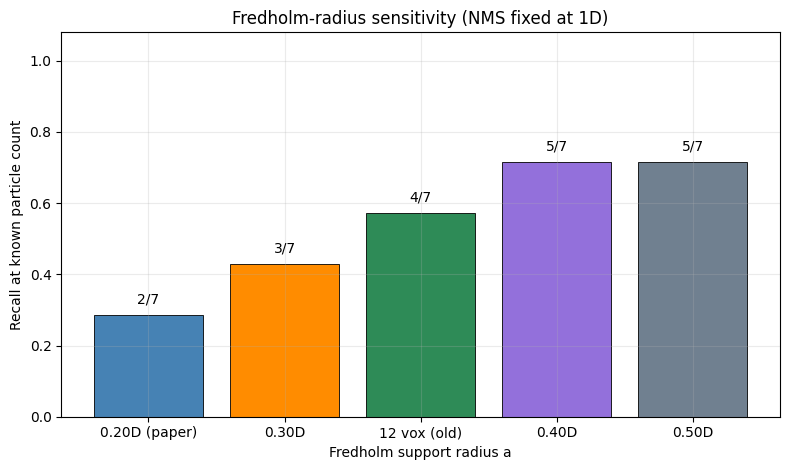

In [27]:
def likelihood_score_for_fredholm_radius(fredholm_radius):
    """Rebuild the complete KLT model and score volume for one support radius."""
    template_side = 2 * int(np.ceil(fredholm_radius)) + 1

    swept_eigvals_by_order = []
    swept_eigfuncs_by_order = []
    for ell in range(MAX_ANGULAR_ORDER):
        values, functions, _ = solve_radial_fredholm_equation(
            Gx,
            ell,
            fredholm_radius,
            BANDLIMIT,
            K=LEGENDRE_ORDER,
        )
        swept_eigvals_by_order.append(values)
        swept_eigfuncs_by_order.append(functions)

    swept_eigvals_matrix = np.asarray(swept_eigvals_by_order)
    swept_eigfuncs_matrix = np.asarray(swept_eigfuncs_by_order)
    swept_flat_eigvals = swept_eigvals_matrix.reshape(-1)
    swept_flat_eigfuncs = (
        swept_eigfuncs_matrix.transpose(0, 2, 1)
        .reshape(-1, LEGENDRE_ORDER)
    )
    swept_flat_orders = np.repeat(
        np.arange(MAX_ANGULAR_ORDER), LEGENDRE_ORDER
    )

    swept_sort_idx = np.argsort(swept_flat_eigvals)[::-1]
    swept_flat_eigvals = swept_flat_eigvals[swept_sort_idx]
    swept_flat_eigfuncs = swept_flat_eigfuncs[swept_sort_idx]
    swept_flat_orders = swept_flat_orders[swept_sort_idx]
    swept_positive = swept_flat_eigvals > np.spacing(1)
    swept_flat_eigvals = swept_flat_eigvals[swept_positive]
    swept_flat_eigfuncs = swept_flat_eigfuncs[swept_positive]
    swept_flat_orders = swept_flat_orders[swept_positive]

    swept_truncate_idx = radial_mode_truncation_index(
        swept_flat_eigvals,
        swept_flat_orders,
        ENERGY_FRACTION,
    )
    swept_eigvals = swept_flat_eigvals[:swept_truncate_idx]
    swept_eigfuncs = swept_flat_eigfuncs[:swept_truncate_idx]
    swept_orders = swept_flat_orders[:swept_truncate_idx]

    swept_axis = np.arange(-(template_side // 2), template_side // 2 + 1)
    swept_Z, swept_Y, swept_X = np.meshgrid(
        swept_axis, swept_axis, swept_axis, indexing="ij"
    )
    swept_r = np.sqrt(swept_Z**2 + swept_Y**2 + swept_X**2)
    swept_support = swept_r <= fredholm_radius
    swept_rho_uniform, swept_rho_inverse = np.unique(
        swept_r[swept_support], return_inverse=True
    )

    swept_rho_leg_a = fredholm_radius * (legendre_nodes + 1) / 2
    swept_rho_leg_c = BANDLIMIT * (legendre_nodes + 1) / 2
    swept_r_grid_uniform = np.outer(swept_rho_uniform, swept_rho_leg_c)
    swept_r_grid_legendre = np.outer(swept_rho_leg_a, swept_rho_leg_c)
    swept_max_order = int(swept_orders.max()) + 1
    swept_H_uniform = np.asarray([
        Hn(swept_r_grid_uniform, ell) for ell in range(swept_max_order)
    ])[swept_orders]
    swept_H_legendre = np.asarray([
        Hn(swept_r_grid_legendre, ell) for ell in range(swept_max_order)
    ])[swept_orders]

    swept_frequency_measure = (
        BANDLIMIT / 2
        * legendre_weights
        * Gx
        * swept_rho_leg_c**2
    )
    swept_spatial_measure = (
        fredholm_radius / 2
        * legendre_weights
        * swept_rho_leg_a**2
    )
    swept_sign = np.where(swept_orders % 2, -1, 1)
    swept_psi = (
        swept_H_uniform * swept_frequency_measure[None, None, :]
    ) @ (swept_sign[:, None, None] * swept_H_legendre)
    swept_eigfuncs_uniform = (
        np.einsum(
            "bik,k,bk->bi",
            swept_psi,
            swept_spatial_measure,
            swept_eigfuncs,
        )
        / swept_eigvals[:, None]
    )

    swept_radial_templates = np.zeros(
        (len(swept_eigvals), template_side, template_side, template_side),
        dtype=swept_eigfuncs_uniform.dtype,
    )
    swept_radial_templates[:, swept_support] = (
        swept_eigfuncs_uniform[:, swept_rho_inverse]
    )
    swept_templates, swept_template_radial_index, _ = (
        expand_spherical_harmonic_templates(
            swept_radial_templates,
            swept_orders,
            swept_Z,
            swept_Y,
            swept_X,
        )
    )
    swept_template_eigvals = swept_eigvals[swept_template_radial_index]

    swept_n_templates = swept_templates.shape[0]
    swept_template_matrix = jnp.asarray(
        swept_templates.reshape(swept_n_templates, template_side**3).T
    )
    swept_Q, swept_R = jnp.linalg.qr(swept_template_matrix, mode="reduced")
    swept_H = (
        (
            swept_R * jnp.asarray(swept_template_eigvals)[None, :]
        ) @ jnp.conj(swept_R.T)
        + noise_variance * jnp.eye(swept_R.shape[0])
    )
    swept_H_eigvals, swept_P = jnp.linalg.eigh(swept_H)
    swept_D = (1 / noise_variance) - (1 / swept_H_eigvals)
    swept_mu = jnp.linalg.slogdet(swept_H / noise_variance)[1]
    swept_D = swept_D[::-1]
    swept_P = swept_P[:, ::-1]
    swept_B = swept_Q @ swept_P
    swept_kernels = swept_B.T.reshape(
        -1, template_side, template_side, template_side
    )
    swept_score_shape = tuple(np.array(tomogram.shape) - template_side + 1)
    swept_score_init = jnp.zeros(swept_score_shape, dtype=jnp.float32)

    def swept_score_body(i, accumulated_score):
        kernel = jnp.conj(jnp.flip(swept_kernels[i], axis=(0, 1, 2)))
        response = jax.scipy.signal.fftconvolve(
            whitened, kernel, mode="valid"
        )
        return accumulated_score + swept_D[i] * jnp.abs(response)**2

    swept_score = jax.lax.fori_loop(
        0,
        swept_kernels.shape[0],
        swept_score_body,
        swept_score_init,
    ) - swept_mu
    swept_score_np = np.asarray(jax.block_until_ready(swept_score))
    return {
        "score": swept_score_np,
        "template_side": template_side,
        "radial_eigenpairs": len(swept_eigvals),
        "angular_templates": len(swept_templates),
    }


fredholm_sweep_specs = [
    ("0.20D (paper)", 0.20 * PARTICLE_DIAMETER_VOXELS),
    ("0.30D", 0.30 * PARTICLE_DIAMETER_VOXELS),
    ("12 vox (old)", 12.0),
    ("0.40D", 0.40 * PARTICLE_DIAMETER_VOXELS),
    ("0.50D", 0.50 * PARTICLE_DIAMETER_VOXELS),
]

fredholm_sweep_rows = []
fredholm_sweep_assignments = {}
for label, swept_radius in fredholm_sweep_specs:
    start = time.perf_counter()
    if np.isclose(swept_radius, FREDHOLM_RADIUS):
        swept_result = {
            "score": score_np,
            "template_side": TEMPLATE_SIDE,
            "radial_eigenpairs": len(eigvals),
            "angular_templates": len(templates),
        }
    else:
        swept_result = likelihood_score_for_fredholm_radius(swept_radius)

    swept_candidate_indices, swept_candidate_values = (
        ranked_local_maxima_nms_3d(
            swept_result["score"],
            radius=PARTICLE_DIAMETER_VOXELS,
            max_picks=KNOWN_PARTICLE_COUNT,
        )
    )
    swept_centers = (
        swept_candidate_indices + swept_result["template_side"] // 2
    )
    swept_picks = np.column_stack((swept_centers, swept_candidate_values))
    swept_assignment = known_count_assignment(
        swept_picks, gt, MATCH_TOLERANCE
    )
    swept_recovered = int(swept_assignment["picked"].sum())
    fredholm_sweep_assignments[label] = swept_assignment
    fredholm_sweep_rows.append({
        "setting": label,
        "Fredholm radius / D": swept_radius / PARTICLE_DIAMETER_VOXELS,
        "Fredholm radius (voxels)": swept_radius,
        "template side": swept_result["template_side"],
        "radial eigenpairs": swept_result["radial_eigenpairs"],
        "angular templates": swept_result["angular_templates"],
        "particles recovered": swept_recovered,
        "recall": swept_recovered / KNOWN_PARTICLE_COUNT,
        "elapsed (s)": time.perf_counter() - start,
    })
    print(
        f"{label}: a={swept_radius:.2f}, side={swept_result['template_side']}, "
        f"recovered={swept_recovered}/{KNOWN_PARTICLE_COUNT}"
    )

fredholm_sweep = pd.DataFrame(fredholm_sweep_rows)
display(fredholm_sweep.style.format({
    "Fredholm radius / D": "{:.3f}",
    "Fredholm radius (voxels)": "{:.2f}",
    "recall": "{:.3f}",
    "elapsed (s)": "{:.2f}",
}))

fig, ax = plt.subplots(figsize=(8, 4.8))
bars = ax.bar(
    fredholm_sweep["setting"],
    fredholm_sweep["recall"],
    color=["steelblue", "darkorange", "seagreen", "mediumpurple", "slategray"],
    edgecolor="black",
    linewidth=0.6,
)
for bar, recovered in zip(bars, fredholm_sweep["particles recovered"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.025,
        f"{recovered}/{KNOWN_PARTICLE_COUNT}",
        ha="center",
        va="bottom",
    )
ax.set_ylim(0, 1.08)
ax.set_xlabel("Fredholm support radius a")
ax.set_ylabel("Recall at known particle count")
ax.set_title("Fredholm-radius sensitivity (NMS fixed at 1D)")
plt.tight_layout()

## Overlay high likelihood on the raw tomogram

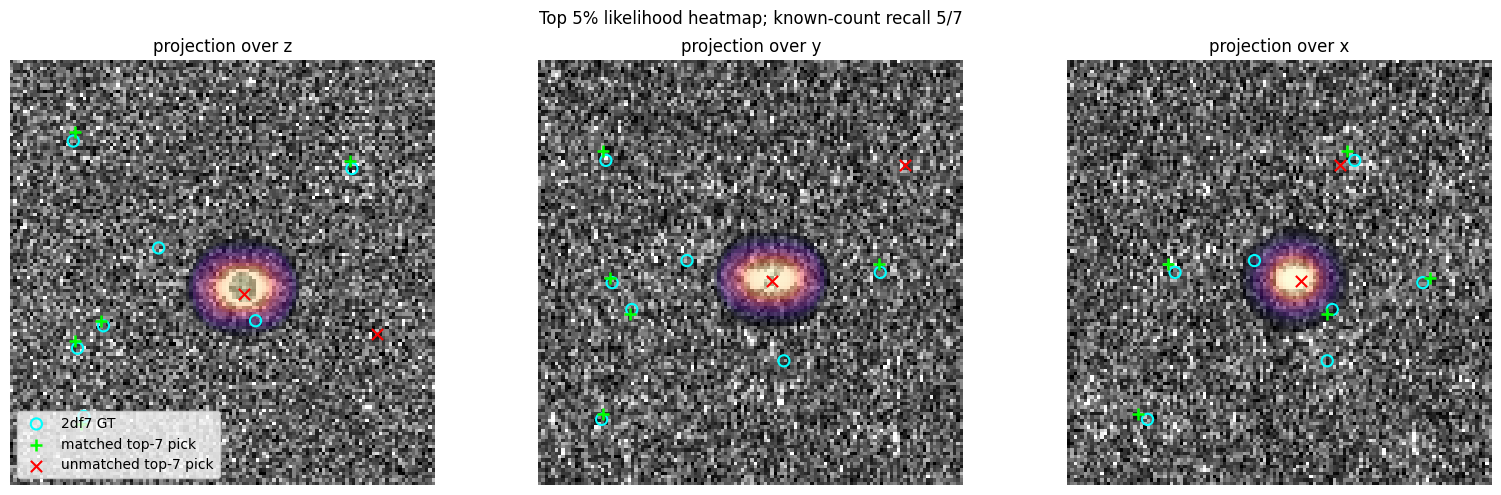

In [28]:
offset = TEMPLATE_SIDE // 2
score_on_roi = np.full(
    tomogram.shape,
    score_np.min(),
    dtype=np.float32,
)
score_on_roi[
    offset:offset + score_np.shape[0],
    offset:offset + score_np.shape[1],
    offset:offset + score_np.shape[2],
] = score_np

selected_picks = picks[:, :3]
matched_pick_mask = assignment["picked"].to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
raw_mips = [
    raw_tomogram.max(axis=0),
    raw_tomogram.max(axis=1),
    raw_tomogram.max(axis=2),
]
score_mips = [
    np.max(score_on_roi, axis=0),
    np.max(score_on_roi, axis=1),
    np.max(score_on_roi, axis=2),
]
gt_plot = [gt[:, [2, 1]], gt[:, [2, 0]], gt[:, [1, 0]]]
pick_plot = [
    selected_picks[:, [2, 1]],
    selected_picks[:, [2, 0]],
    selected_picks[:, [1, 0]],
]
titles = ["projection over z", "projection over y", "projection over x"]
for ax, raw, heat, gt2, pred2, title in zip(
    axes, raw_mips, score_mips, gt_plot, pick_plot, titles
):
    ax.imshow(robust_standardize(raw), cmap="gray")
    lo = np.percentile(heat, 95)
    overlay = np.ma.masked_where(heat < lo, heat)
    ax.imshow(overlay, cmap="magma", alpha=0.55)
    ax.scatter(gt2[:, 0], gt2[:, 1], s=65, facecolors="none",
               edgecolors="cyan", linewidths=1.5, label="2df7 GT")
    ax.scatter(pred2[matched_pick_mask, 0], pred2[matched_pick_mask, 1],
               marker="+", s=85, color="lime", linewidths=1.8,
               label="matched top-7 pick")
    ax.scatter(pred2[~matched_pick_mask, 0], pred2[~matched_pick_mask, 1],
               marker="x", s=65, color="red", linewidths=1.5,
               label="unmatched top-7 pick")
    ax.set_title(title)
    ax.axis("off")
axes[0].legend(loc="lower left")
plt.suptitle(
    f"Top 5% likelihood heatmap; known-count recall "
    f"{num_recovered}/{KNOWN_PARTICLE_COUNT}"
)
plt.tight_layout()

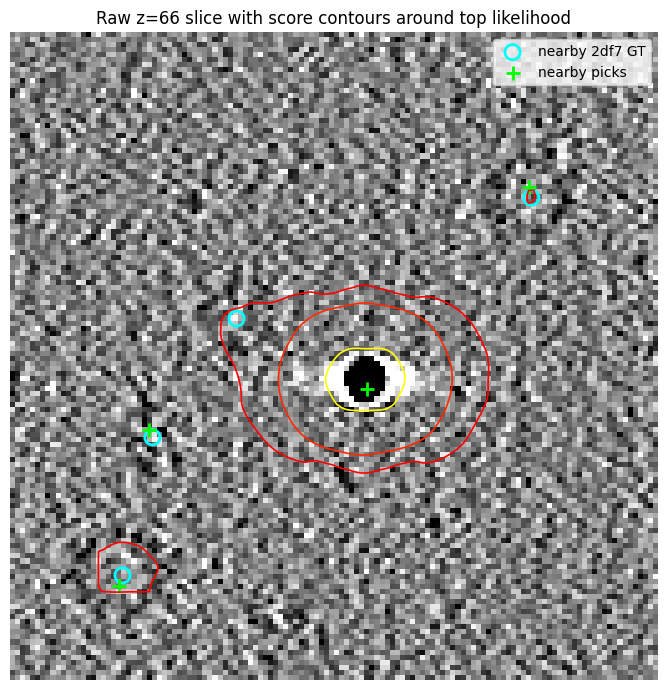

In [29]:
top_center = picks[0, :3].astype(int)
z = top_center[0]
raw_slice = raw_tomogram[z]
score_slice = score_on_roi[z]

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(robust_standardize(raw_slice), cmap="gray")
levels = np.nanpercentile(score_slice, [90, 95, 99])
ax.contour(score_slice, levels=np.unique(levels), cmap="autumn", linewidths=1.2)
near_gt = gt[np.abs(gt[:, 0] - z) <= PARTICLE_DIAMETER_VOXELS / 2]
near_pick = selected_picks[
    np.abs(selected_picks[:, 0] - z) <= PARTICLE_DIAMETER_VOXELS / 2
]
ax.scatter(near_gt[:, 2], near_gt[:, 1], s=120, facecolors="none",
           edgecolors="cyan", linewidths=2, label="nearby 2df7 GT")
ax.scatter(near_pick[:, 2], near_pick[:, 1], marker="+", s=100,
           color="lime", linewidths=2, label="nearby picks")
ax.set_title(f"Raw z={z} slice with score contours around top likelihood")
ax.legend()
ax.axis("off")
plt.tight_layout()

## Package evaluation of all 12 particles, including partial boundary particles

The manual analysis above uses only the seven 2df7 particles whose nominal diameter is fully contained in the artificial $128^3$ ROI. This secondary stress test keeps the ROI exactly as cropped and includes all 12 ground-truth centers, so five targets have incomplete particle support at an ROI boundary.

Unlike the preceding cells, the algorithm is not reconstructed manually here. We call the package's end-to-end `KLTParticleDetector3D.process_tomogram()` method with the best settings from the controlled sweeps: Fredholm radius $a=0.4D$ and NMS radius $0.5D$. We assume the total count of 12 is known and disable the score threshold, making this a top-12 recall diagnostic. Results are separated into fully supported and boundary-truncated targets because the latter also lie partly outside the valid-convolution candidate-center domain.

In [30]:
ALL_PARTICLE_COUNT = len(gt_all)
assert ALL_PARTICLE_COUNT == 12

BLACKBOX_FREDHOLM_RADIUS = 0.4 * PARTICLE_DIAMETER_VOXELS
BLACKBOX_TEMPLATE_SIDE = 2 * int(np.ceil(BLACKBOX_FREDHOLM_RADIUS)) + 1
BLACKBOX_NMS_RADIUS = 0.5 * PARTICLE_DIAMETER_VOXELS

blackbox_detector = KLTParticleDetector3D(
    raw_tomogram,
    particle_diameter=PARTICLE_DIAMETER_VOXELS,
    mgscale=1.0,
    num_particles=ALL_PARTICLE_COUNT,
    legendre_order=LEGENDRE_ORDER,
    threshold=-np.inf,
    max_iter=ALS_MAX_ITER,
    max_order=MAX_ANGULAR_ORDER,
    psd_patch_size=PSD_PATCH_SIZE,
    fredholm_radius=BLACKBOX_FREDHOLM_RADIUS,
    template_side=BLACKBOX_TEMPLATE_SIDE,
    bandpass_low_fraction=BANDPASS_LOW_FRACTION,
    bandpass_high_fraction=BANDPASS_HIGH_FRACTION,
    nms_radius=BLACKBOX_NMS_RADIUS,
)

start = time.perf_counter()
blackbox_num_picks, blackbox_picks = blackbox_detector.process_tomogram()
blackbox_elapsed = time.perf_counter() - start
assert blackbox_num_picks == ALL_PARTICLE_COUNT

print(f"Package execution: {blackbox_elapsed:.2f} s")
print({
    "ground-truth centers": ALL_PARTICLE_COUNT,
    "Fredholm radius": BLACKBOX_FREDHOLM_RADIUS,
    "template side": BLACKBOX_TEMPLATE_SIDE,
    "NMS radius": BLACKBOX_NMS_RADIUS,
    "package picks": blackbox_num_picks,
})
display(pd.DataFrame(
    blackbox_picks,
    columns=["z", "y", "x", "normalized score"],
))

Package execution: 7.46 s
{'ground-truth centers': 12, 'Fredholm radius': 13.200000000000001, 'template side': 29, 'NMS radius': 16.5, 'package picks': 12}


,z,y,x,normalized score
0,66.0,70.0,70.0,1.000000
1,60.0,58.0,48.0,0.029381
2,75.0,77.0,27.0,0.023482
3,90.0,80.0,71.0,0.021642
4,65.0,105.0,22.0,0.021402
5,107.0,24.0,22.0,0.020450
6,27.0,85.0,19.0,0.020345
7,57.0,113.0,53.0,0.019488
8,35.0,113.0,75.0,0.018664
9,101.0,14.0,39.0,0.018607


In [31]:
blackbox_assignment = known_count_assignment(
    blackbox_picks,
    gt_all,
    MATCH_TOLERANCE,
)
blackbox_gt_indices = blackbox_assignment["gt_index"].to_numpy(dtype=int) - 1
blackbox_assignment.insert(
    2,
    "support group",
    np.where(evaluable[blackbox_gt_indices], "fully supported", "ROI boundary"),
)

blackbox_group_rows = []
for group_name, group_mask in [
    ("fully supported", evaluable),
    ("ROI boundary", ~evaluable),
]:
    group_assignments = blackbox_assignment[
        blackbox_assignment["support group"] == group_name
    ]
    group_matched = group_assignments[group_assignments["picked"]]
    target_count = int(group_mask.sum())
    recovered = int(group_matched.shape[0])
    blackbox_group_rows.append({
        "support group": group_name,
        "target count": target_count,
        "recovered": recovered,
        "recall": recovered / target_count,
        "mean matched distance (voxels)": group_matched["distance_voxels"].mean(),
        "maximum matched distance (voxels)": group_matched["distance_voxels"].max(),
    })

blackbox_group_summary = pd.DataFrame(blackbox_group_rows)
blackbox_total_recovered = int(blackbox_assignment["picked"].sum())
print(
    f"All-particle package result: {blackbox_total_recovered}/"
    f"{ALL_PARTICLE_COUNT} recovered "
    f"(recall={blackbox_total_recovered / ALL_PARTICLE_COUNT:.3f})"
)
display(blackbox_group_summary.style.format({
    "recall": "{:.3f}",
    "mean matched distance (voxels)": "{:.2f}",
    "maximum matched distance (voxels)": "{:.2f}",
}))
display(blackbox_assignment.style.format({
    "score": "{:.3f}",
    "distance_voxels": "{:.2f}",
    "distance_in_D": "{:.3f}",
}))

All-particle package result: 11/12 recovered (recall=0.917)


,support group,target count,recovered,recall,mean matched distance (voxels),maximum matched distance (voxels)
0,fully supported,7,7,1.000,3.09,4.19
1,ROI boundary,5,4,0.800,5.46,6.37


,pick_rank,gt_index,support group,score,pick_z,pick_y,pick_x,gt_z,gt_y,gt_x,distance_voxels,distance_in_D,picked
0,1,9,ROI boundary,1.000,66.000000,70.000000,70.000000,120.400289,104.012547,18.417478,82.32,2.495,False
1,2,5,fully supported,0.029,60.000000,58.000000,48.000000,59.880879,56.072757,44.277719,4.19,0.127,True
2,3,11,fully supported,0.023,75.000000,77.000000,27.000000,74.620440,79.536170,27.658604,2.65,0.080,True
3,4,10,fully supported,0.022,90.000000,80.000000,71.000000,90.085572,78.010331,73.486220,3.19,0.097,True
4,5,12,fully supported,0.021,65.000000,105.000000,22.000000,66.519936,106.812956,21.737552,2.38,0.072,True
5,6,1,fully supported,0.020,107.000000,24.000000,22.000000,107.731569,23.868912,18.579984,3.50,0.106,True
6,7,2,fully supported,0.020,27.000000,85.000000,19.000000,29.689009,86.287265,19.857473,3.10,0.094,True
7,8,7,ROI boundary,0.019,57.000000,113.000000,53.000000,57.804739,118.766635,55.587781,6.37,0.193,True
8,9,3,ROI boundary,0.019,35.000000,113.000000,75.000000,34.800776,118.046456,76.004611,5.15,0.156,True
9,10,4,ROI boundary,0.019,101.000000,14.000000,39.000000,100.612967,9.672923,41.825557,5.18,0.157,True


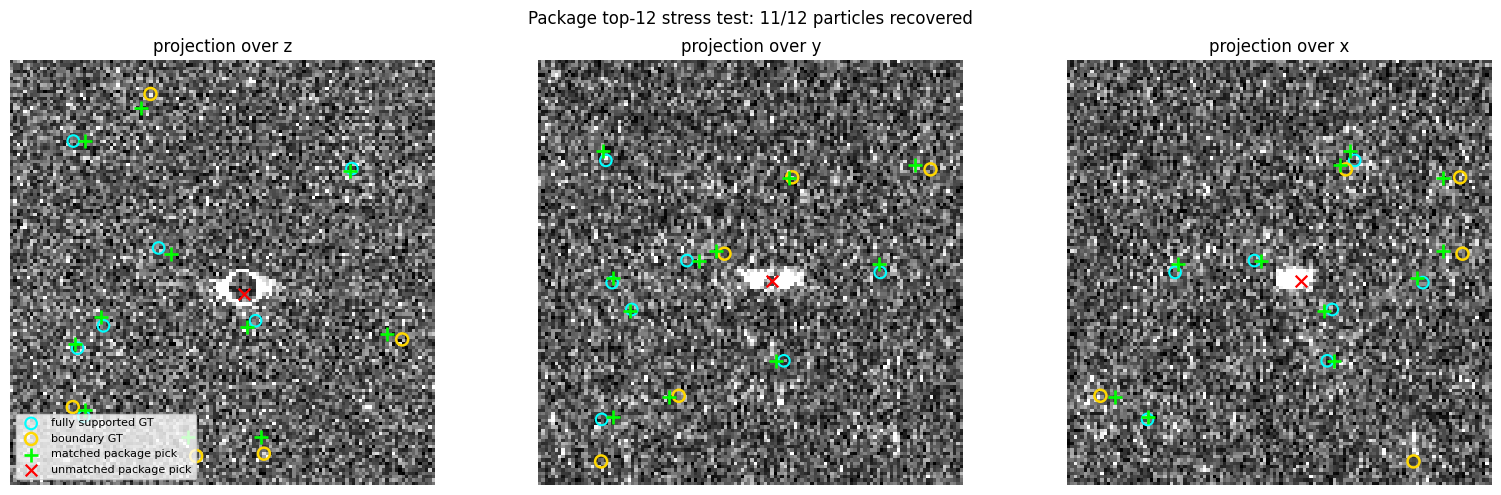

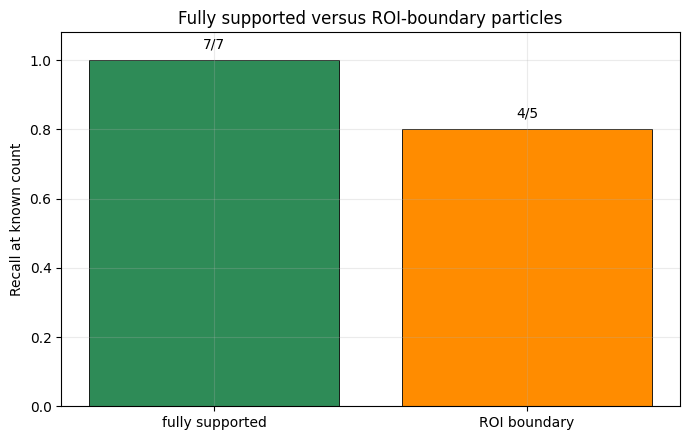

In [32]:
blackbox_matched_pick_mask = blackbox_assignment["picked"].to_numpy()
blackbox_selected_picks = blackbox_picks[:, :3]
interior_gt = gt_all[evaluable]
boundary_gt = gt_all[~evaluable]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
blackbox_raw_mips = [
    raw_tomogram.max(axis=0),
    raw_tomogram.max(axis=1),
    raw_tomogram.max(axis=2),
]
blackbox_interior_plot = [
    interior_gt[:, [2, 1]],
    interior_gt[:, [2, 0]],
    interior_gt[:, [1, 0]],
]
blackbox_boundary_plot = [
    boundary_gt[:, [2, 1]],
    boundary_gt[:, [2, 0]],
    boundary_gt[:, [1, 0]],
]
blackbox_pick_plot = [
    blackbox_selected_picks[:, [2, 1]],
    blackbox_selected_picks[:, [2, 0]],
    blackbox_selected_picks[:, [1, 0]],
]
for ax, raw, interior2, boundary2, pred2, title in zip(
    axes,
    blackbox_raw_mips,
    blackbox_interior_plot,
    blackbox_boundary_plot,
    blackbox_pick_plot,
    ["projection over z", "projection over y", "projection over x"],
):
    ax.imshow(robust_standardize(raw), cmap="gray")
    ax.scatter(
        interior2[:, 0], interior2[:, 1], s=70,
        facecolors="none", edgecolors="cyan", linewidths=1.5,
        label="fully supported GT",
    )
    ax.scatter(
        boundary2[:, 0], boundary2[:, 1], s=75,
        facecolors="none", edgecolors="gold", linewidths=1.8,
        label="boundary GT",
    )
    ax.scatter(
        pred2[blackbox_matched_pick_mask, 0],
        pred2[blackbox_matched_pick_mask, 1],
        marker="+", s=90, color="lime", linewidths=1.9,
        label="matched package pick",
    )
    ax.scatter(
        pred2[~blackbox_matched_pick_mask, 0],
        pred2[~blackbox_matched_pick_mask, 1],
        marker="x", s=70, color="red", linewidths=1.6,
        label="unmatched package pick",
    )
    ax.set_title(title)
    ax.axis("off")
axes[0].legend(loc="lower left", fontsize=8)
plt.suptitle(
    f"Package top-12 stress test: {blackbox_total_recovered}/"
    f"{ALL_PARTICLE_COUNT} particles recovered"
)
plt.tight_layout()

fig, ax = plt.subplots(figsize=(7, 4.5))
group_bars = ax.bar(
    blackbox_group_summary["support group"],
    blackbox_group_summary["recall"],
    color=["seagreen", "darkorange"],
    edgecolor="black",
    linewidth=0.6,
)
for bar, recovered, target_count in zip(
    group_bars,
    blackbox_group_summary["recovered"],
    blackbox_group_summary["target count"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.025,
        f"{recovered}/{target_count}",
        ha="center",
        va="bottom",
    )
ax.set_ylim(0, 1.08)
ax.set_ylabel("Recall at known count")
ax.set_title("Fully supported versus ROI-boundary particles")
plt.tight_layout()